<a href="https://www.kaggle.com/code/sonawanelalitsunil/international-hotel-booking-analytics-ml-96-02?scriptVersionId=259385190" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/international-hotel-booking-analytics/users.csv
/kaggle/input/international-hotel-booking-analytics/booking_db.sqlite
/kaggle/input/international-hotel-booking-analytics/reviews.csv
/kaggle/input/international-hotel-booking-analytics/hotels.csv


## Title:
International Hotel Booking Analytics

## Description:
This project focuses on analyzing international hotel booking data to uncover patterns, trends, and key insights that influence customer behavior and business performance. By examining factors such as booking channels, lead times, cancellation rates, customer demographics, seasonal demand, room preferences, and pricing strategies, the analysis aims to provide a deeper understanding of the hospitality industry’s dynamics. The insights generated can help hotels optimize revenue management, reduce cancellations, improve customer satisfaction, and design targeted marketing strategies. This comprehensive study combines data preprocessing, exploratory data analysis, and visualization techniques to translate raw booking data into actionable intelligence for decision-makers.

## Import dataset

In [2]:
users = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/users.csv', parse_dates=['join_date'])

reviews = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/reviews.csv', parse_dates=['review_date'])

hotels = pd.read_csv('/kaggle/input/international-hotel-booking-analytics/hotels.csv', encoding='Windows-1252')


In [3]:
print('Users data shape:', users.shape)
print('Reviews data shape:', reviews.shape)
print('Hotels data shape:', hotels.shape)

Users data shape: (2000, 6)
Reviews data shape: (50000, 12)
Hotels data shape: (25, 13)


In [4]:
print('Users data shape:', users.dtypes)
print('Reviews data shape:', reviews.dtypes)
print('Hotels data shape:', hotels.dtypes)

Users data shape: user_id                    int64
user_gender               object
country                   object
age_group                 object
traveller_type            object
join_date         datetime64[ns]
dtype: object
Reviews data shape: review_id                         int64
user_id                           int64
hotel_id                          int64
review_date              datetime64[ns]
score_overall                   float64
score_cleanliness               float64
score_comfort                   float64
score_facilities                float64
score_location                  float64
score_staff                     float64
score_value_for_money           float64
review_text                      object
dtype: object
Hotels data shape: hotel_id                  int64
hotel_name               object
city                     object
country                  object
star_rating               int64
lat                     float64
lon                     float64
cleanliness_b

In [5]:
print('Users data shape:', users.head())
print('Reviews data shape:', reviews.head())
print('Hotels data shape:', hotels.head())

Users data shape:    user_id user_gender         country age_group traveller_type  join_date
0        1      Female  United Kingdom     35-44           Solo 2024-09-29
1        2        Male  United Kingdom     25-34           Solo 2023-11-29
2        3      Female          Mexico     25-34         Family 2022-04-03
3        4        Male           India     35-44         Family 2023-12-02
4        5       Other           Japan     25-34           Solo 2021-12-18
Reviews data shape:    review_id  user_id  hotel_id review_date  score_overall  score_cleanliness  \
0          1     1600         1  2022-10-07            8.7                8.6   
1          2      432         4  2020-03-24            9.1               10.0   
2          3      186        18  2023-12-18            8.8                9.7   
3          4     1403        19  2022-06-22            8.9                9.0   
4          5     1723        17  2022-07-02            9.1                8.9   

   score_comfort  score_f

In [6]:
print('Users data shape:', users.tail())
print('Reviews data shape:', reviews.tail())
print('Hotels data shape:', hotels.tail())

Users data shape:       user_id user_gender      country age_group traveller_type  join_date
1995     1996        Male  Netherlands     45-54         Couple 2020-09-06
1996     1997      Female  South Korea     18-24         Couple 2023-05-24
1997     1998        Male        China     45-54           Solo 2022-12-09
1998     1999      Female        China       55+       Business 2024-12-27
1999     2000        Male  South Korea     35-44         Couple 2022-02-11
Reviews data shape:        review_id  user_id  hotel_id review_date  score_overall  \
49995      49996     1786        24  2022-08-07            8.4   
49996      49997     1739         8  2025-03-05            8.8   
49997      49998     1566         6  2025-05-03            9.1   
49998      49999       10        21  2024-09-27            9.0   
49999      50000     1626        19  2022-02-09            9.2   

       score_cleanliness  score_comfort  score_facilities  score_location  \
49995                8.2            8.

In [7]:
def data_overview(df, name):
    print(f"\nOverview of {name} dataset:")
    print(df.info())
    print(df.head())

data_overview(users, 'Users')
data_overview(reviews, 'Reviews')
data_overview(hotels, 'Hotels')


Overview of Users dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         2000 non-null   int64         
 1   user_gender     2000 non-null   object        
 2   country         2000 non-null   object        
 3   age_group       2000 non-null   object        
 4   traveller_type  2000 non-null   object        
 5   join_date       2000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 93.9+ KB
None
   user_id user_gender         country age_group traveller_type  join_date
0        1      Female  United Kingdom     35-44           Solo 2024-09-29
1        2        Male  United Kingdom     25-34           Solo 2023-11-29
2        3      Female          Mexico     25-34         Family 2022-04-03
3        4        Male           India     35-44         Family 2023-12-02


In [8]:
print('\nMissing values in users:\n', users.isnull().sum())
print('\nMissing values in reviews:\n', reviews.isnull().sum())
print('\nMissing values in hotels:\n', hotels.isnull().sum())


Missing values in users:
 user_id           0
user_gender       0
country           0
age_group         0
traveller_type    0
join_date         0
dtype: int64

Missing values in reviews:
 review_id                0
user_id                  0
hotel_id                 0
review_date              0
score_overall            0
score_cleanliness        0
score_comfort            0
score_facilities         0
score_location           0
score_staff              0
score_value_for_money    0
review_text              0
dtype: int64

Missing values in hotels:
 hotel_id                0
hotel_name              0
city                    0
country                 0
star_rating             0
lat                     0
lon                     0
cleanliness_base        0
comfort_base            0
facilities_base         0
location_base           0
staff_base              0
value_for_money_base    0
dtype: int64


In [9]:
if not np.issubdtype(users['join_date'].dtype, np.datetime64):
    users['join_date'] = pd.to_datetime(users['join_date'], errors='coerce')

if not np.issubdtype(reviews['review_date'].dtype, np.datetime64):
    reviews['review_date'] = pd.to_datetime(reviews['review_date'], errors='coerce')

# Note: In cases where parsing dates fails, errors='coerce' ensures that invalid parsing returns NaT.
print('Data cleaning completed.')

Data cleaning completed.


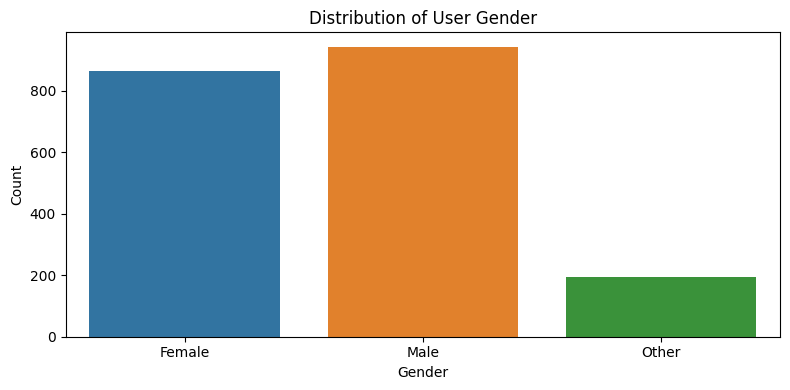

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x='user_gender', data=users)
plt.title('Distribution of User Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


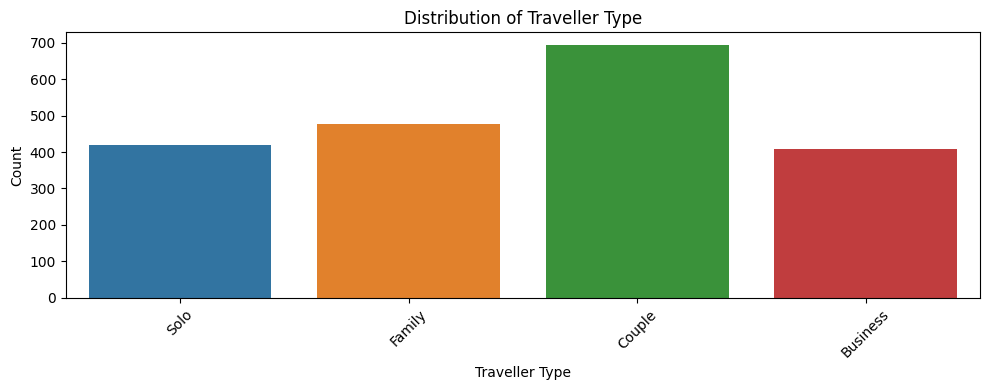

In [11]:
plt.figure(figsize=(10,4))
sns.countplot(x='traveller_type', data=users)
plt.title('Distribution of Traveller Type')
plt.xlabel('Traveller Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

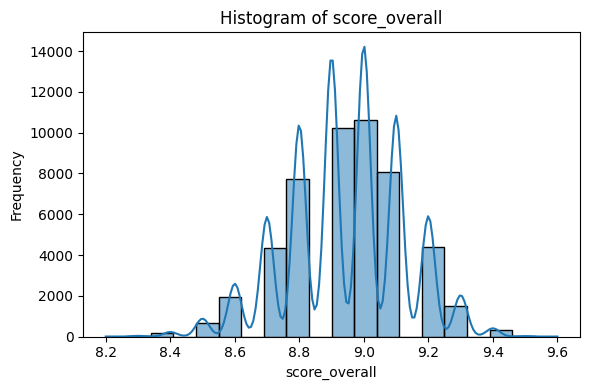

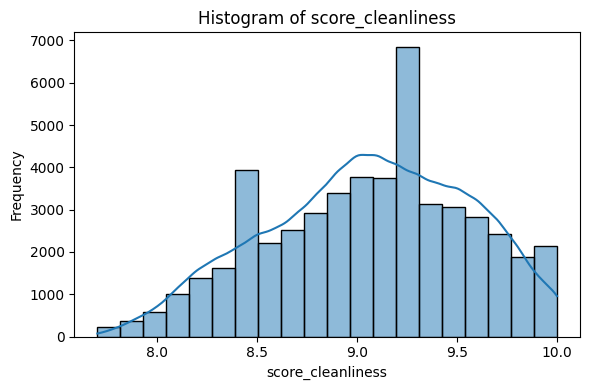

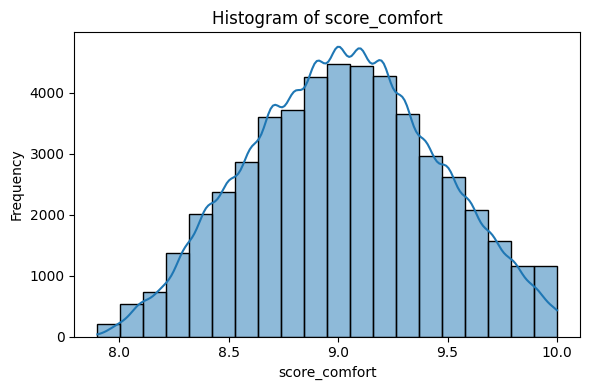

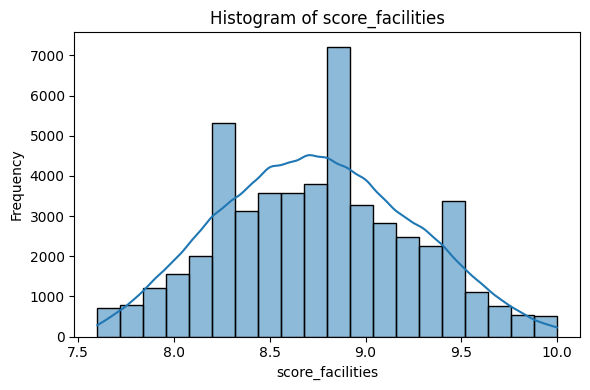

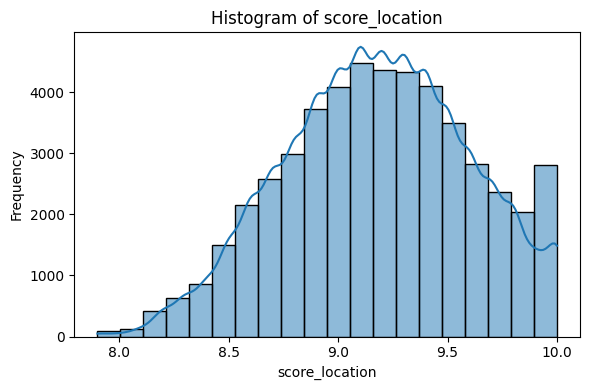

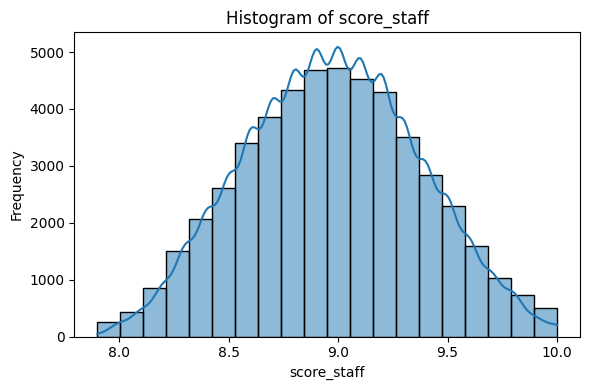

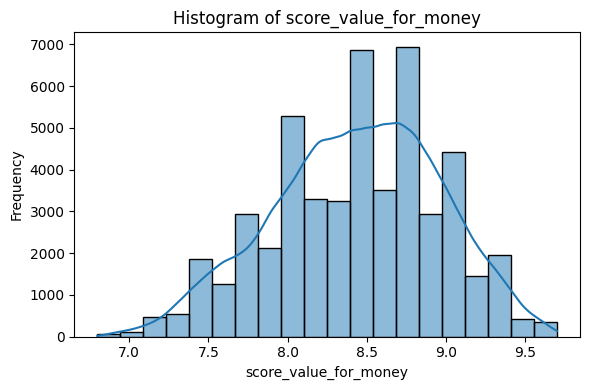

In [12]:
score_cols = ['score_overall', 'score_cleanliness', 'score_comfort', 'score_facilities', 
              'score_location', 'score_staff', 'score_value_for_money']

for col in score_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(reviews[col], kde=True, bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

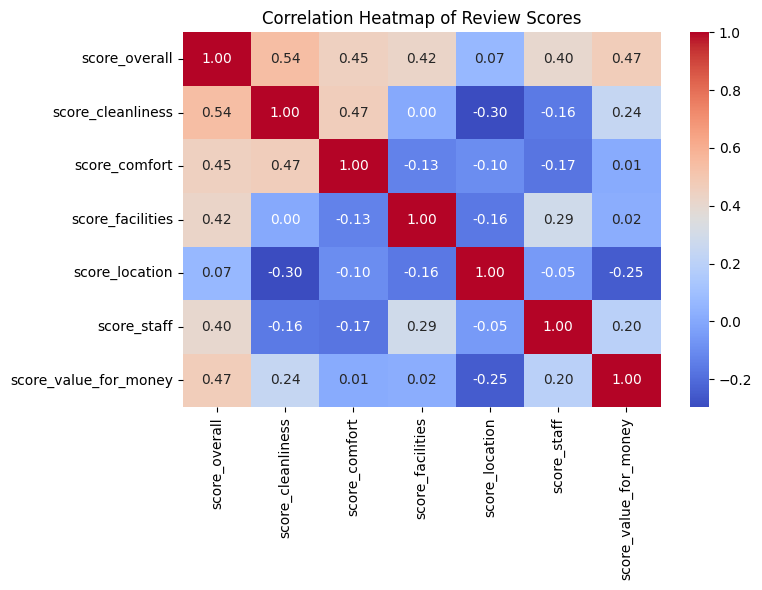

In [13]:
numeric_df = reviews[score_cols]
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(8,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Review Scores')
    plt.tight_layout()
    plt.show()


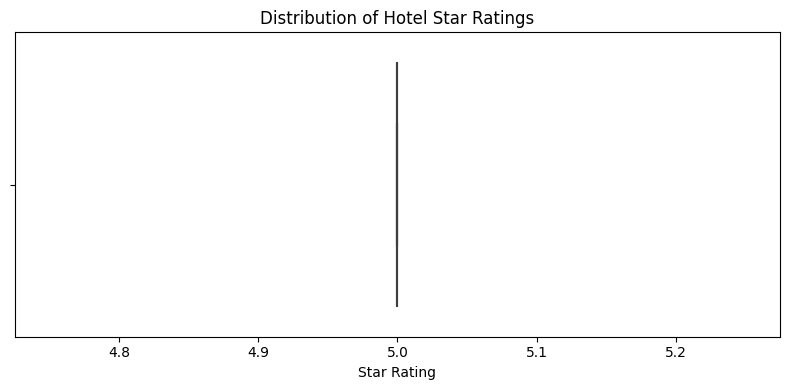

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x='star_rating', data=hotels)
plt.title('Distribution of Hotel Star Ratings')
plt.xlabel('Star Rating')
plt.tight_layout()
plt.show()

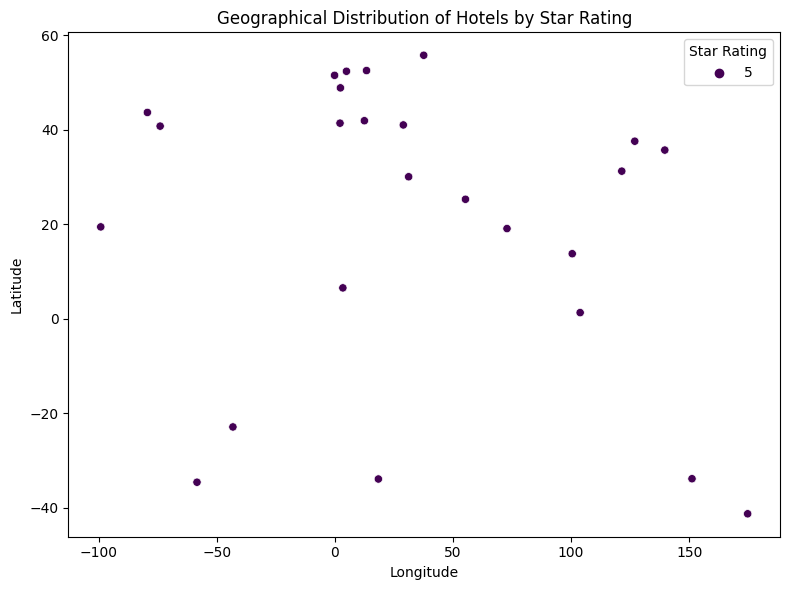

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='lon', y='lat', hue='star_rating', data=hotels, palette='viridis')
plt.title('Geographical Distribution of Hotels by Star Rating')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Star Rating')
plt.tight_layout()
plt.show()

## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

In [17]:
feature_cols = ['score_cleanliness', 'score_comfort', 'score_facilities', 
                'score_location', 'score_staff', 'score_value_for_money']
target_col = 'score_overall'

predict_data = reviews[feature_cols + [target_col]].dropna()
X = predict_data[feature_cols]
y = predict_data[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

In [19]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred) * 100   # convert to percentage
    results.append((name, score))

In [20]:
results_df = pd.DataFrame(results, columns=["Model", "R2 Score (%)"])
print(results_df)


               Model  R2 Score (%)
0  Linear Regression     96.147821
1              Ridge     96.147876
2              Lasso     -0.002019
3      Decision Tree     86.651197
4      Random Forest     95.590431
5  Gradient Boosting     95.650027
6           AdaBoost     85.406112
7                KNN     95.254425
8                SVM     96.026861
9            XGBoost     95.908040


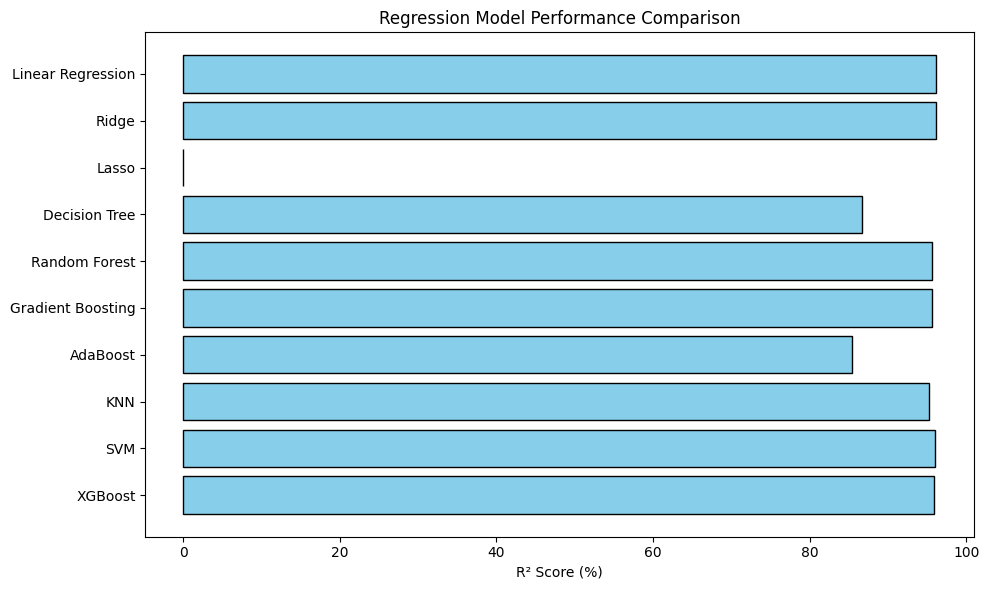

In [21]:
plt.figure(figsize=(10,6))
plt.barh(results_df["Model"], results_df["R2 Score (%)"], color="skyblue", edgecolor="black")
plt.xlabel("R² Score (%)")
plt.title("Regression Model Performance Comparison")
plt.gca().invert_yaxis()  # Highest score at the top
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!!